In [444]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

mpl.style.use("plotstyles.mlpstyle")

PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=pymatching/2025-11-28.csv"
]
pymatching_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)
pymatching_stats = [
    s
    for s in pymatching_stats
    if s.json_metadata.get("d") != 15 and s.json_metadata.get("d") != 13
]

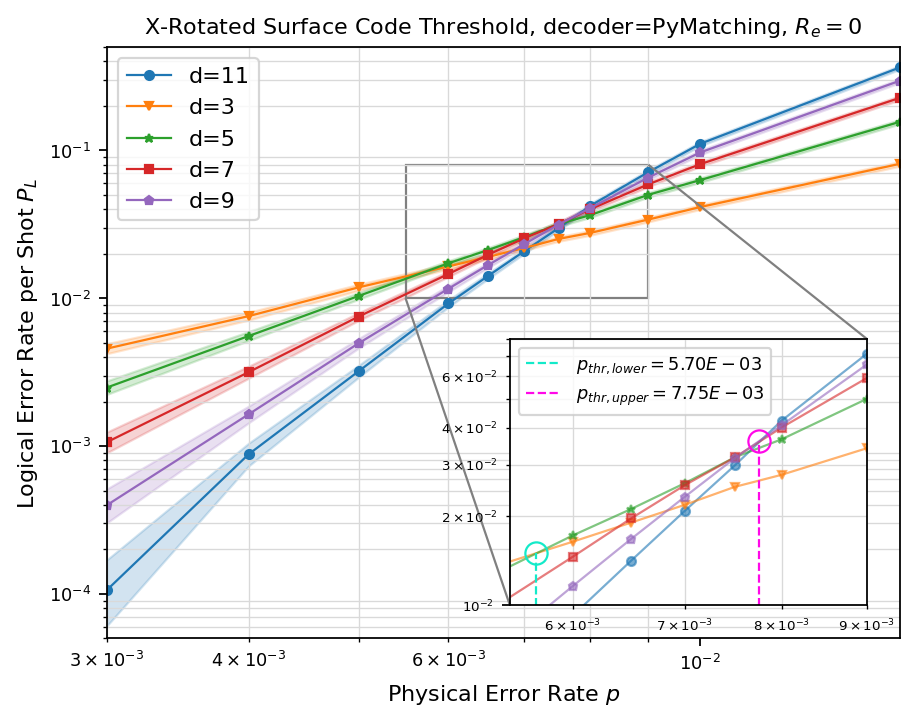

In [445]:
# PYMATCHING PLOT R_e = 0
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "d=" + str(stats.json_metadata["d"]),
    # + stats.json_metadata["decoder"]
    # plot_args_func=lambda idx, curve: dict(markersize=5)
)
ax.loglog()
ax.set_title(
    "X-Rotated Surface Code Threshold, decoder=PyMatching, $R_e=0$",
    fontdict=dict(fontsize=10),
)

ax.set_xlim(3e-3, 1.5e-2)
ax.set_ylim(5e-5, 5e-1)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="both")
# inset axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.5)
axins_ylim = (1e-2, 0.8e-1)
axins_xlim = (5.5e-3, 9e-3)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (5.70e-3, 1.5e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (7.75e-3, 3.6e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey")
ax.legend()
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)
fig.set_dpi(160)

In [446]:
ABLATION_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=SinterMWPFDecoder/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-30.csv",
]
ablation_stats = sinter.read_stats_from_csv_files(*ABLATION_FILES)
for s in ablation_stats:
    # the naming scheme in util.sinter_task.DecoderLib changed slightly since last run
    if s.json_metadata.get("decoder") == "SinterMWPFDecoder":
        s.json_metadata["decoder"] = "mwpf"

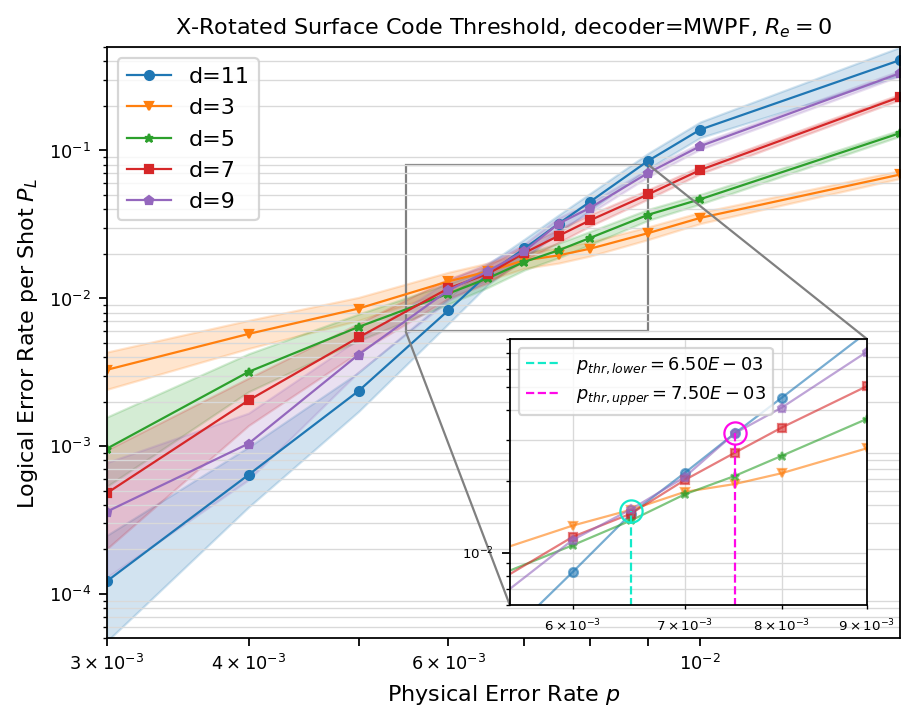

In [447]:
# MWPF PLOT R_e = 0
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=ablation_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "d=" + str(stats.json_metadata["d"]),
    # + stats.json_metadata["decoder"]
    # plot_args_func=lambda idx, curve: dict(markersize=5)
)
ax.loglog()
ax.set_title(
    "X-Rotated Surface Code Threshold, decoder=MWPF, $R_e=0$",
    fontdict=dict(fontsize=10),
)
ax.set_ylim(5e-5, 5e-1)
ax.set_xlim(3e-3, 1.5e-2)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")

# inset axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.5)
axins_ylim = (6e-3, 0.8e-1)
axins_xlim = (5.5e-3, 9e-3)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (6.5e-3, 1.5e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (7.5e-3, 3.2e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey")
ax.legend()
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(160)

In [448]:
ERASURE_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=11,p=0.01,0.02,0.03.csv",
    # "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=9.csv",
]

erasure_stats = sinter.read_stats_from_csv_files(*ERASURE_FILES)

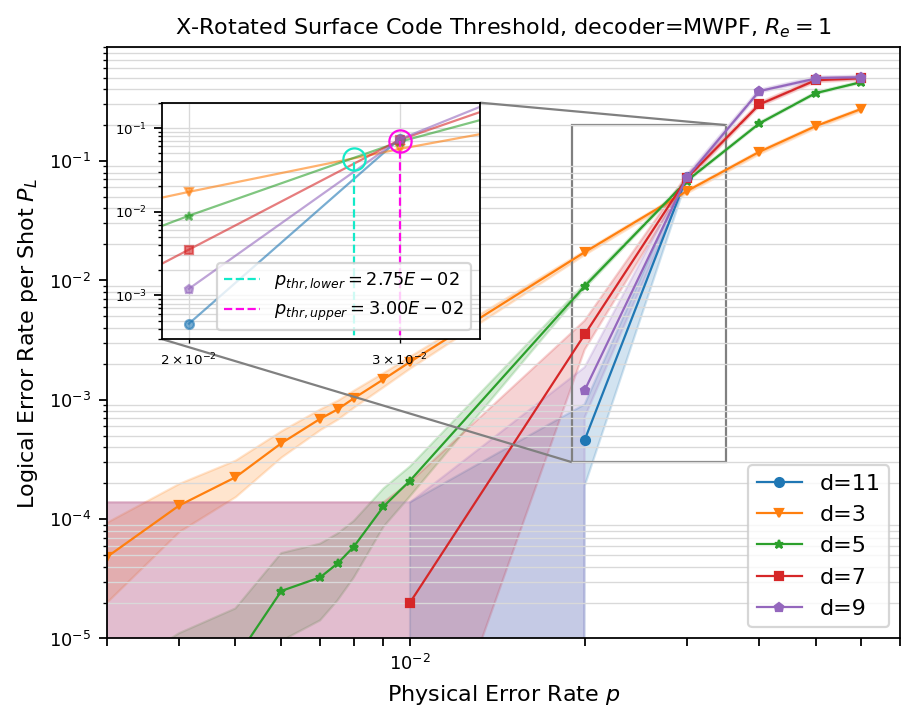

In [449]:
# MWPF PLOT R_e = 1
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "d=" + str(stats.json_metadata["d"]),
    # + stats.json_metadata["decoder"]
    # plot_args_func=lambda idx, curve: dict(markersize=5)
)
ax.loglog()
ax.set_title(
    "X-Rotated Surface Code Threshold, decoder=MWPF, $R_e=1$",
    fontdict=dict(fontsize=10),
)

ax.set_xlim(3e-3, 7e-2)
ax.set_ylim(1e-5, 9e-1)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="both")

# inset axes
axins = inset_axes(ax, width="40%", height="40%", loc="upper left", borderpad=2.5)
axins_ylim = (3e-4, 2e-1)
axins_xlim = (1.9e-2, 3.5e-2)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (2.75e-2, 4.2e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (3e-2, 7e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey")
ax.legend(loc="lower right")
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(160)

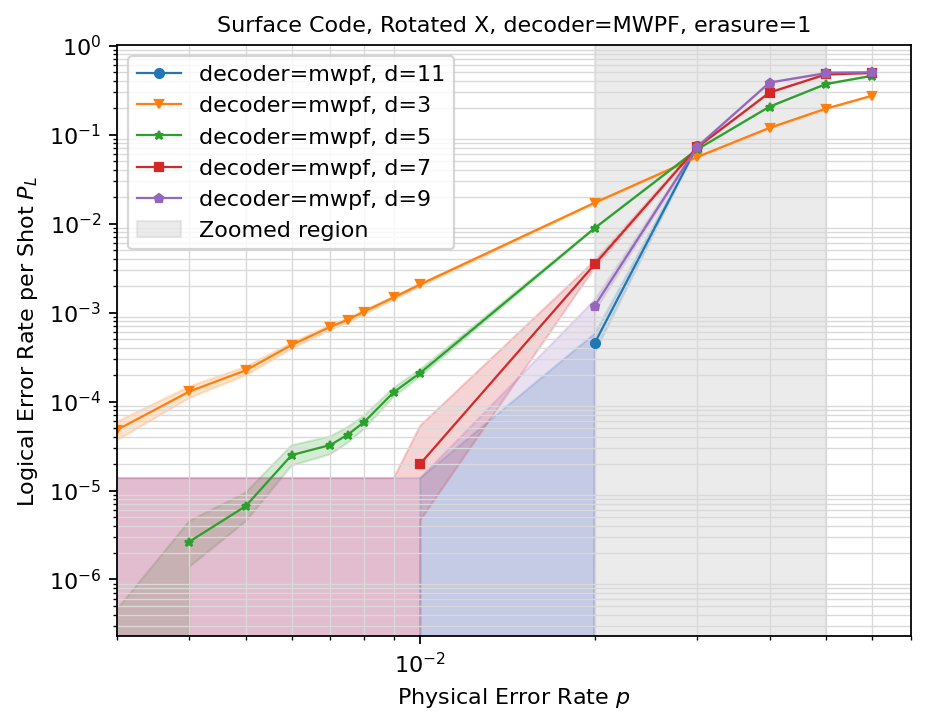

In [450]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
    highlight_max_likelihood_factor=2,
)
ax.loglog()
# ax.set_ylim(1e-6, 1e0)
ax.set_xlim(3e-3, 7e-2)
ax.set_title(
    "Surface Code, Rotated X, decoder=MWPF, erasure=1", fontdict=dict(fontsize=10)
)
plt.axvspan(2e-2, 5e-2, color="silver", label="Zoomed region", alpha=0.3)

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)

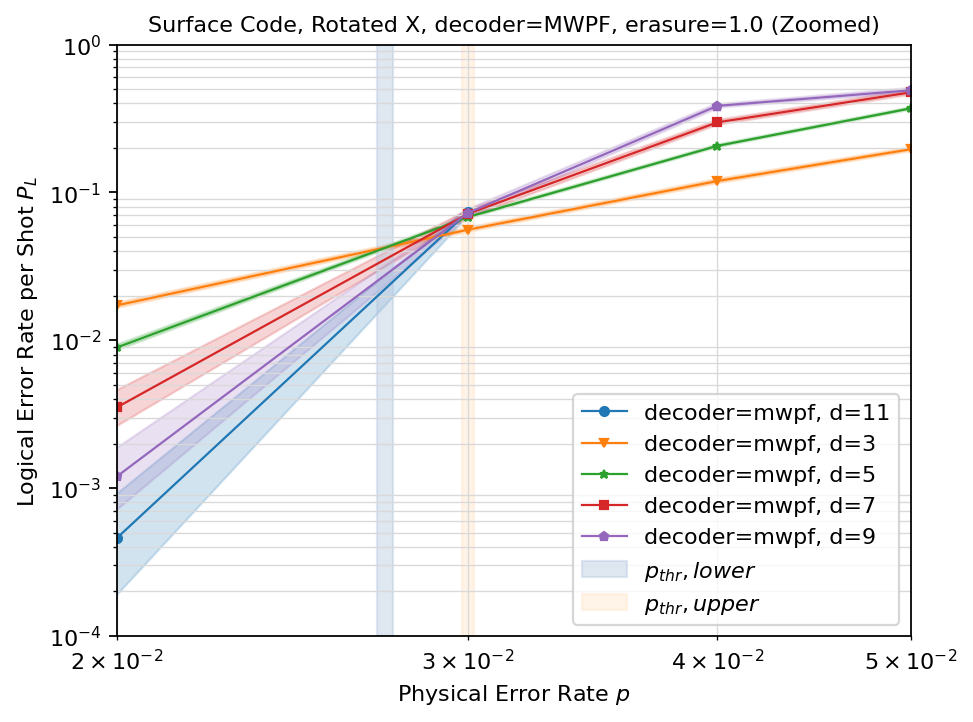

In [451]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_ylim(1e-4, 1e0)
ax.set_xlim(2e-2, 5e-2)
ax.set_title(
    "Surface Code, Rotated X, decoder=MWPF, erasure=1.0 (Zoomed)",
    fontdict=dict(fontsize=10),
)
plt.axvspan(
    2.70e-2, 2.75e-2, color="lightsteelblue", label="$p_{thr}, lower$", alpha=0.4
)
plt.axvspan(2.98e-2, 3.02e-2, color="bisque", label="$p_{thr}, upper$", alpha=0.4)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)

In [452]:
PYMATCHING_CUSTOM_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=HeraldedEraseDecoder/erasure=1.0/2025-11-30_pthresh.csv"
]
custom_stats = sinter.read_stats_from_csv_files(*PYMATCHING_CUSTOM_FILES)

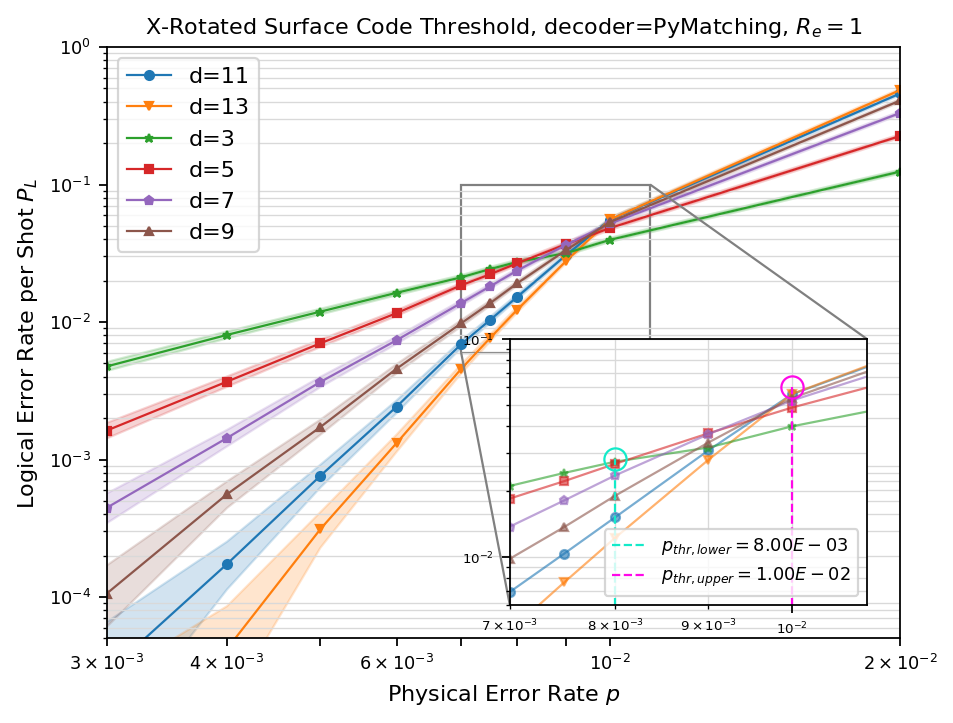

In [461]:
# MWPF PLOT R_e = 0
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "d=" + str(stats.json_metadata["d"]),
    # + stats.json_metadata["decoder"]
    # plot_args_func=lambda idx, curve: dict(markersize=5)
)
ax.loglog()
ax.set_title(
    "X-Rotated Surface Code Threshold, decoder=PyMatching, $R_e=1$",
    fontdict=dict(fontsize=10),
)
ax.set_ylim(5e-5, 1e0)
ax.set_xlim(3e-3, 2e-2)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")

# inset axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.5)
axins_ylim = (6e-3, 1e-1)
axins_xlim = (7e-3, 1.1e-2)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (8e-3, 2.8e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (1e-2, 6e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey")
ax.legend()
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(160)

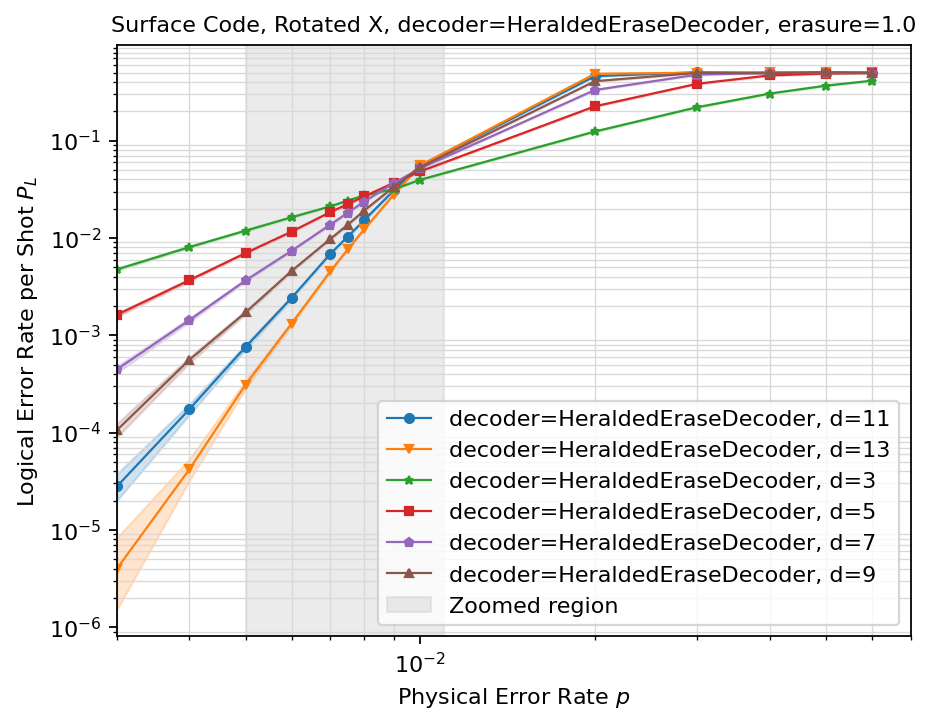

In [454]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
    highlight_max_likelihood_factor=2,
)
ax.loglog()
# ax.set_ylim(1e-6, 1e0)
ax.set_xlim(3e-3, 7e-2)
ax.set_title(
    "Surface Code, Rotated X, decoder=HeraldedEraseDecoder, erasure=1.0",
    fontdict=dict(fontsize=10),
)
plt.axvspan(5e-3, 1.1e-2, color="silver", label="Zoomed region", alpha=0.3)

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)

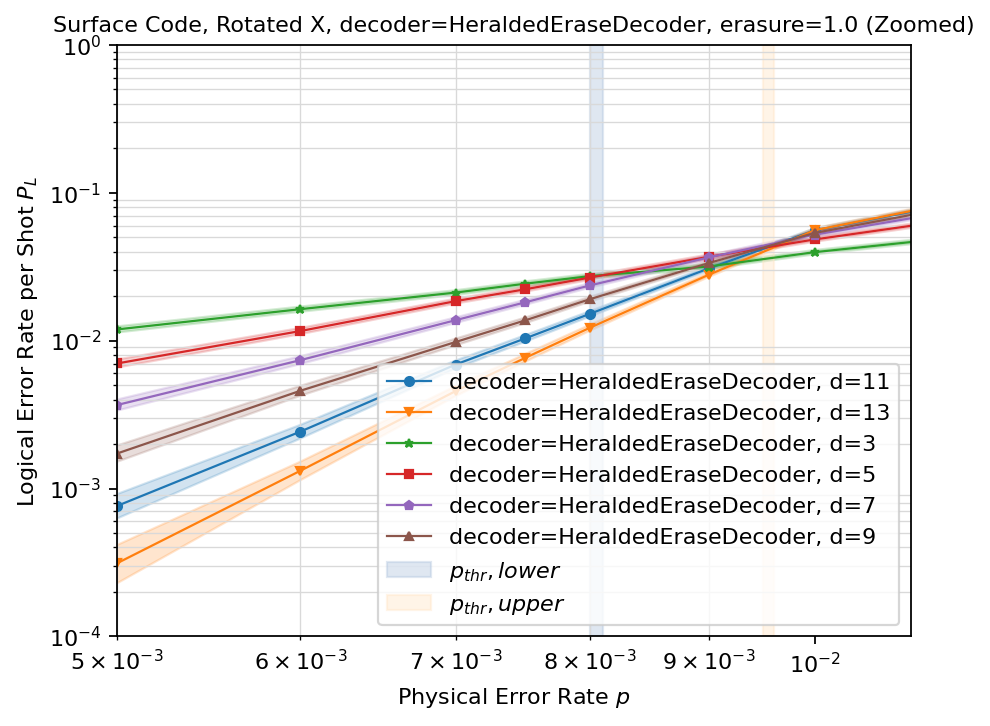

In [455]:
fig, ax = plt.subplots(1, 1)


sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_ylim(1e-4, 1e0)
ax.set_xlim(5e-3, 1.1e-2)
ax.set_title(
    "Surface Code, Rotated X, decoder=HeraldedEraseDecoder, erasure=1.0 (Zoomed)",
    fontdict=dict(fontsize=10),
)
plt.axvspan(8.0e-3, 8.1e-3, color="lightsteelblue", label="$p_{thr}, lower$", alpha=0.4)
plt.axvspan(9.5e-3, 9.6e-3, color="bisque", label="$p_{thr}, upper$", alpha=0.4)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)

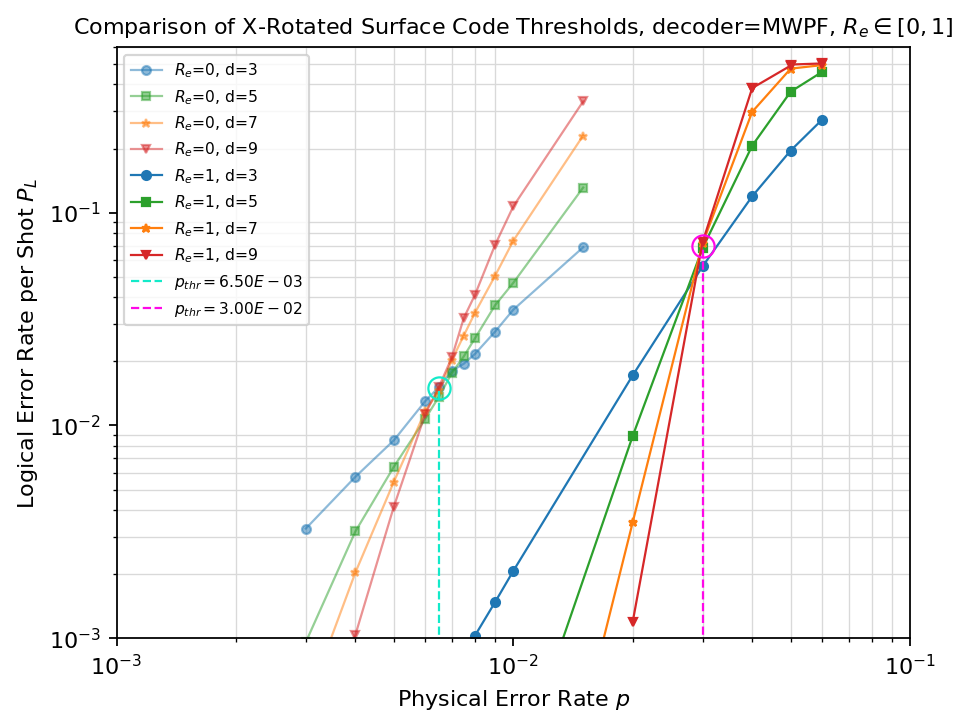

In [460]:
# combined

fig, ax = plt.subplots(1, 1)


def filter_func(stats):
    # filter d=3,5,7,9 to avoid cluttering the plot
    return stats.json_metadata.get("d") in [3, 5, 7, 9]


def get_marker(d):
    markers = {3: "circle", 5: "triangle", 7: "star", 9: "square"}
    return markers[d]


def get_colors(d, decoder):
    colors = {
        "pymatching": {3: "blue", 5: "orange", 7: "green", 9: "red"},
        "mwpf": {3: "blue", 5: "orange", 7: "green", 9: "red"},
        "HeraldedEraseDecoder": {3: "blue", 5: "orange", 7: "green", 9: "red"},
    }
    return colors[decoder][d]


def plot_args(index, curve_id):
    if index < 4:
        return dict(alpha=0.5)
    else:
        return dict()


# def group_func(stats):
#     decoder = stats.json_metadata.get("decoder")
#     R_e = bool(stats.json_metadata.get("p_erase"))
#     d = stats.json_metadata.get("d")
#     label = f"{decoder}, d={d}"
#     result = dict(
#         label=label,
#         marker=get_marker(d),
#         color=get_colors(d, decoder),
#         sort=decoder + str(d),
#     )
#     if decoder == "pymatching":
#         result["linestyle"] = "."
#         result["label"] = result["label"] + ", $R_e=0$"
#     if decoder == "mwpf":
#         result["linestyle"] = "-"
#         if R_e:
#             result["label"] = result["label"] + ", $R_e=1$"
#         else:
#             result["label"] = result["label"] + ", $R_e=1$"
#     if decoder == "HeraldedEraseDecoder":
#         result["linestyle"] = "."
#     return result


def group_func(stats):
    decoder = stats.json_metadata.get("decoder")
    R_e = int(bool(stats.json_metadata.get("p_erase")))
    d = stats.json_metadata.get("d")
    label = f"$R_e$={R_e}, d={d}"
    result = dict(
        label=label,
        marker=get_marker(d),
        color=get_colors(d, decoder),
        sort=str(R_e) + str(d),
    )
    if decoder == "pymatching":
        result["linestyle"] = "."
        result["label"] = result["label"] + ", $R_e=0$"
    if decoder == "mwpf":
        result["linestyle"] = "-"
        # if R_e:
        #     result["label"] = result["label"] + ", $R_e=1$"
        # else:
        #     result["label"] = result["label"] + ", $R_e=1$"
    if decoder == "HeraldedEraseDecoder":
        result["linestyle"] = "."
    return result


sinter.plot_error_rate(
    ax=ax,
    stats=ablation_stats + erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    highlight_max_likelihood_factor=1,
    filter_func=filter_func,
    plot_args_func=plot_args,
)
ax.loglog()
ax.set_ylim(1e-3, 6e-1)
ax.set_xlim(1e-3, 1e-1)
ax.set_title(
    "Comparison of X-Rotated Surface Code Thresholds, decoder=MWPF, $R_e \in [0, 1]$",
    fontdict=dict(fontsize=10),
)

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")

pthr_lower = (6.5e-3, 1.5e-2)
ax.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
ax.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (3e-2, 7e-2)
ax.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
ax.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr}$" + f"$={pthr_upper[0]:.2E}$",
)
ax.legend(fontsize=7)
fig.set_dpi(160)